# Buy or Wait? — Reproducible EDA

This executed notebook studies participant-facing data, not hidden labels. Request-level analyses use evaluation users; inventory and representative image triage explicitly include all supplied data. Each analysis produces quantified observations and implementation implications. There are 13 figures. Re-run from the repository root with `python plan/run_eda.py`.

The analysis implementation lives in `plan/eda_analysis.py`; each section below displays its exact source before execution. Outputs are exported to `eda_outputs/`. No financial recommendations are produced.

In [1]:
from pathlib import Path
import sys, inspect
root = Path.cwd() if (Path.cwd() / 'dataset').is_dir() else Path.cwd().parent
sys.path.insert(0, str(root / 'plan'))
from eda_analysis import Analysis
from IPython.display import Code, display
a = Analysis()

## Input inventory and structural integrity

### Query / Analysis

Count supplied rows, missing cells, duplicate IDs, orphan references and image coverage. This section uses all supplied tables.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

In [2]:
display(Code(inspect.getsource(Analysis.integrity), language="python"))
a.integrity()

def integrity(self):
        keys = {'financial_profiles':'user_id','financial_events':'event_id','requests':'request_id',
                'sample_requests':'request_id','messages':'message_id','images':'image_id','request_payment_options':'payment_option_id'}
        rows = pd.DataFrame([{'table': k, 'rows': len(v), 'blank_cells': int(v.eq('').sum().sum()),
                              'duplicate_primary_ids': int(v[keys[k]].duplicated().sum()) if k in keys else None} for k,v in self.t.items()])
        allreq = pd.concat([self.t['requests'],self.t['sample_requests']],ignore_index=True)
        refs = {'user_id':set(self.t['financial_profiles'].user_id), 'request_id':set(allreq.request_id),
                'related_event_id':set(self.t['financial_events'].event_id), 'linked_event_id':set(self.t['financial_events'].event_id)}
        orphans = {k: sum(int((~v[k].isin(target) & v[k].ne('')).sum()) for v in self.t.values() if k in v) for k,target in refs.items()}
        image_exists = self.t['images'].image_id.map(lambda x:(ROOT/'dataset/media/images'/f'{x}.png').is_file())
        missing = self.t['financial_events'].query("amount == ''")
        covered = missing.event_id.isin(self.t['images'].loc[image_exists,'related_event_id'])
        self.table('inventory', rows)
        self.findings('integrity', {'inventory':rows.to_dict('records'),'orphans':orphans,'missing_amounts':len(missing),'missing_amounts_with_image':int(covered.sum()),
            'output_ids_match':set(self.t['output'].request_id)==set(self.t['requests'].request_id)}, [
            f"The supplied tables contain {len(self.r)} evaluation requests and {len(self.t['sample_requests'])} samples; evaluation users contribute {len(self.e):,} events.",
            f"Primary-key duplicates total {int(rows.duplicate_primary_ids.sum())}; unresolved populated foreign keys total {sum(orphans.values())}.",
            f"All-data missing amounts: {len(missing)}; {int(covered.sum())} have existing linked PNGs. Their numeric values are still unextracted."],
            [('DETERMINISTIC','Validate identifiers, typed fields and joins at ingestion; preserve blank amounts until evidence resolves them.'),
             ('LLM_REQUIRED','Image-backed amounts need visual interpretation, including selecting the correct monetary field; EDA does not prove an LLM is the only possible extractor.')])

,table,rows,blank_cells,duplicate_primary_ids
0,exchange_rates,134,0,NaN
1,financial_events,25342,47745,0.0
2,financial_profiles,275,220,0.0
3,images,16,0,0.0
4,messages,215,263,0.0
5,output,250,1750,NaN
6,request_payment_options,790,275,0.0
7,requests,250,0,0.0
8,sample_requests,25,7,0.0


### Extract Insights

- The supplied tables contain 250 evaluation requests and 25 samples; evaluation users contribute 23,054 events.
- Primary-key duplicates total 0; unresolved populated foreign keys total 0.
- All-data missing amounts: 16; 16 have existing linked PNGs. Their numeric values are still unextracted.

### Implications for the Financial Agent

- **DETERMINISTIC:** Validate identifiers, typed fields and joins at ingestion; preserve blank amounts until evidence resolves them.
- **LLM_REQUIRED:** Image-backed amounts need visual interpretation, including selecting the correct monetary field; EDA does not prove an LLM is the only possible extractor.

## Request distributions, money and deadlines

### Query / Analysis

Count evaluation request types, compare amounts within currency, divide by positive raw headroom, and calculate date differences. Headroom is not safe-to-pay capacity.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

def requests(self):
        c = self.r.request_type.value_counts(); fig,ax=plt.subplots(); self.bar(ax,c,'Evaluation requests by type','Requests','Request type'); self.plot('01_request_types',fig)
        self.findings('request_types', c.to_dict(), [f"Type counts range from {c.min()} to {c.max()} across {len(c)} types.",
            f"Largest type share is {c.max()/len(self.r):.1%}; no single type dominates the evaluation population."], [('DETERMINISTIC','Apply the same safety constraints across all request types; do not infer affordability from type frequency.')])
        fig,axes=plt.subplots(1,2,figsize=(13,5)); currencies=sorted(self.r.home_currency.unique())
        axes[0].boxplot([self.r.loc[self.r.home_currency.eq(c),'requested_amount'] for c in currencies],tick_labels=currencies)
        axes[0].set(yscale='log',title='Requested amounts by home currency',xlabel='Home currency (amounts not comparable across groups)',ylabel='Requested amount (native units; log scale)')
        ratio=self.r.amount_headroom_ratio.dropna(); axes[1].hist(ratio,bins=25,color='#287b8e'); axes[1].set(title='Request amount / positive raw headroom',xlabel='Ratio (1 = entire raw headroom)',ylabel='Requests'); self.plot('02_amount_headroom',fig)
        monetary=self.r.groupby('home_currency').requested_amount.agg(['count','min','median','max']).reset_index(); self.table('amounts_by_currency',monetary)
        self.findings('amount_headroom',{'by_currency':monetary.to_dict('records'),'nonpositive_headroom':int(self.r.headroom.le(0).sum()),'ratio_quantiles':ratio.quantile([.25,.5,.75,.95,1]).to_dict(),'ratio_above_one':int(ratio.gt(1).sum())},[
            f"{len(ratio)} requests have positive headroom; {self.r.headroom.le(0).sum()} have zero or negative headroom and are excluded from ratios.",
            f"{ratio.gt(1).sum()}/{len(ratio)} ({ratio.gt(1).mean():.1%}) requests exceed raw headroom; median ratio is {ratio.median():.2f}, 95th percentile {ratio.quantile(.95):.2f}.",
            f"Within-currency max/median request ratios range from {(monetary['max']/monetary['median']).min():.1f} to {(monetary['max']/monetary['median']).max():.1f}."],
            [('DETERMINISTIC','Raw headroom is balance minus reserve, not 90-day safe spending. Do not mix native currency amounts.'),('STATISTICAL','Forecast commitments before interpreting a low request/headroom ratio as affordable.')])
        d=self.r.deadline_days; fig,ax=plt.subplots(); ax.hist(d,bins=np.arange(0,101,7),color='#287b8e'); ax.set(title='Time available to complete evaluation requests',xlabel='Days from request to deadline',ylabel='Requests'); self.plot('03_deadlines',fig)
        self.findings('deadlines',{'quantiles':d.quantile([0,.25,.5,.75,1]).to_dict(),'within_30_days':int(d.le(30).sum())},[
            f"Deadlines span {d.min()}–{d.max()} days; median {d.median():.0f} days.",f"{d.le(30).sum()}/{len(d)} ({d.le(30).mean():.1%}) must complete within 30 days."], [('DETERMINISTIC','Compute completion eligibility using each request date and deadline, independently of the forecast horizon.')])

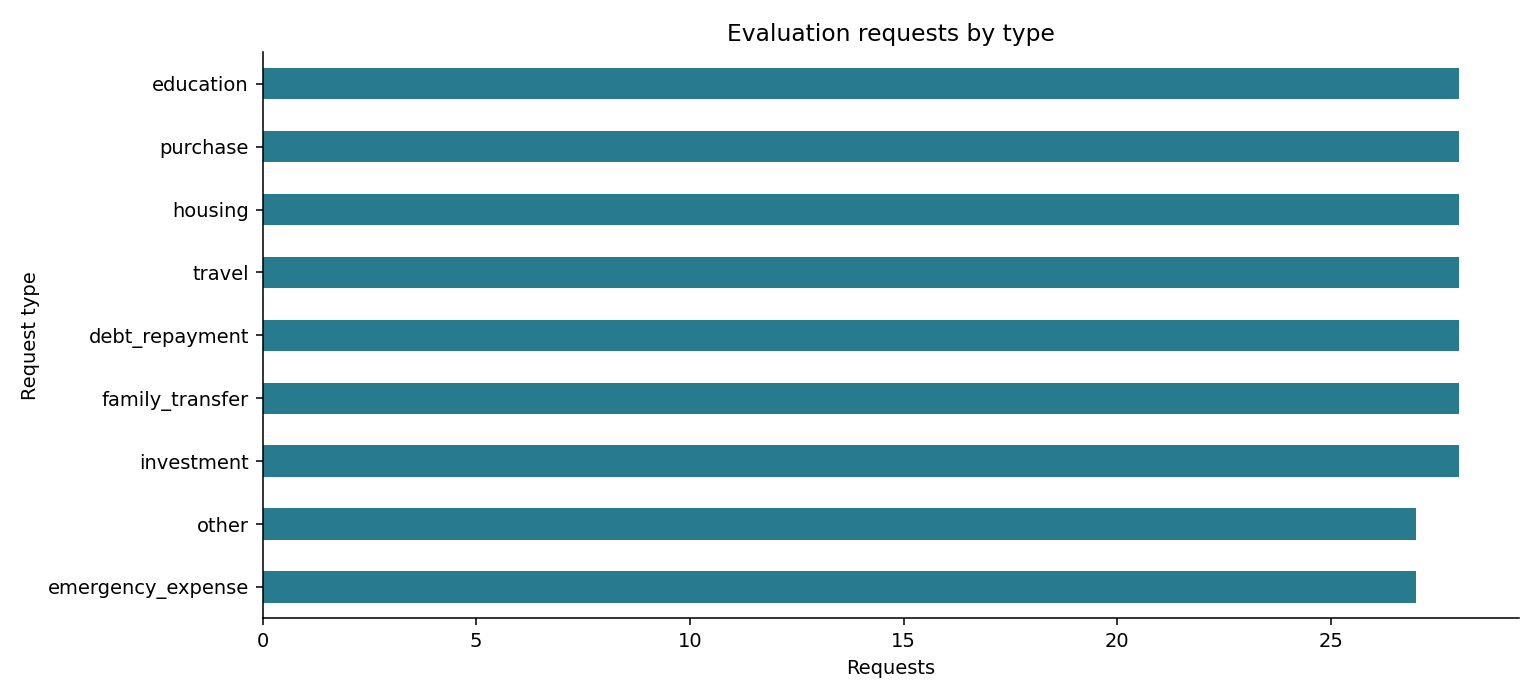

### Extract Insights

- Type counts range from 27 to 28 across 9 types.
- Largest type share is 11.2%; no single type dominates the evaluation population.

### Implications for the Financial Agent

- **DETERMINISTIC:** Apply the same safety constraints across all request types; do not infer affordability from type frequency.

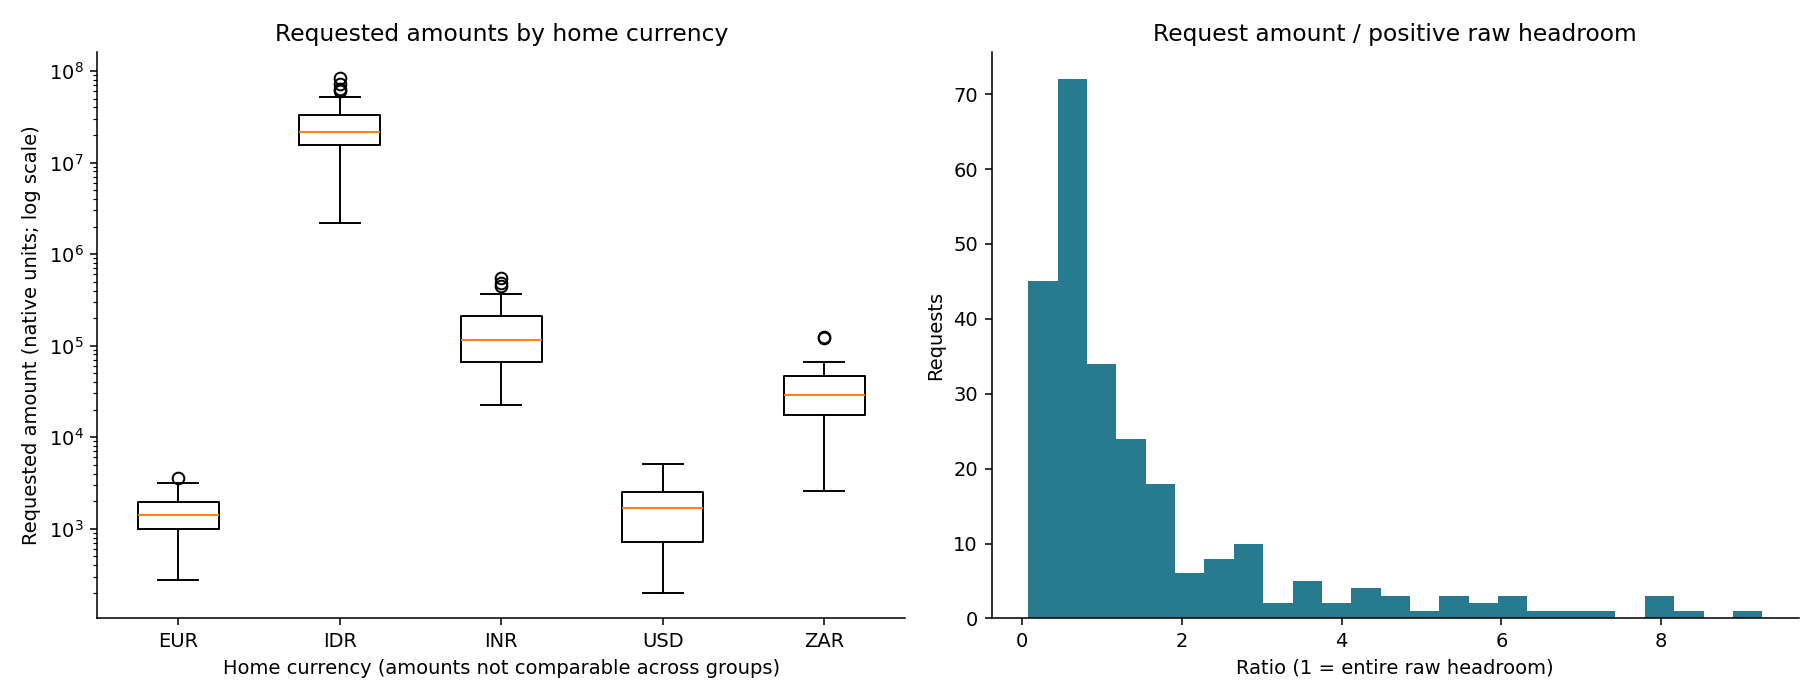

,home_currency,count,min,median,max
0,EUR,54,271.70,1423.4,3537.6
1,IDR,50,2191000.00,21584000.0,83923000.0
2,INR,60,22200.00,115500.0,553000.0
3,USD,39,199.89,1699.2,5059.2
4,ZAR,47,2560.00,29062.0,124278.0


### Extract Insights

- 250 requests have positive headroom; 0 have zero or negative headroom and are excluded from ratios.
- 111/250 (44.4%) requests exceed raw headroom; median ratio is 0.88, 95th percentile 5.57.
- Within-currency max/median request ratios range from 2.5 to 4.8.

### Implications for the Financial Agent

- **DETERMINISTIC:** Raw headroom is balance minus reserve, not 90-day safe spending. Do not mix native currency amounts.
- **STATISTICAL:** Forecast commitments before interpreting a low request/headroom ratio as affordable.

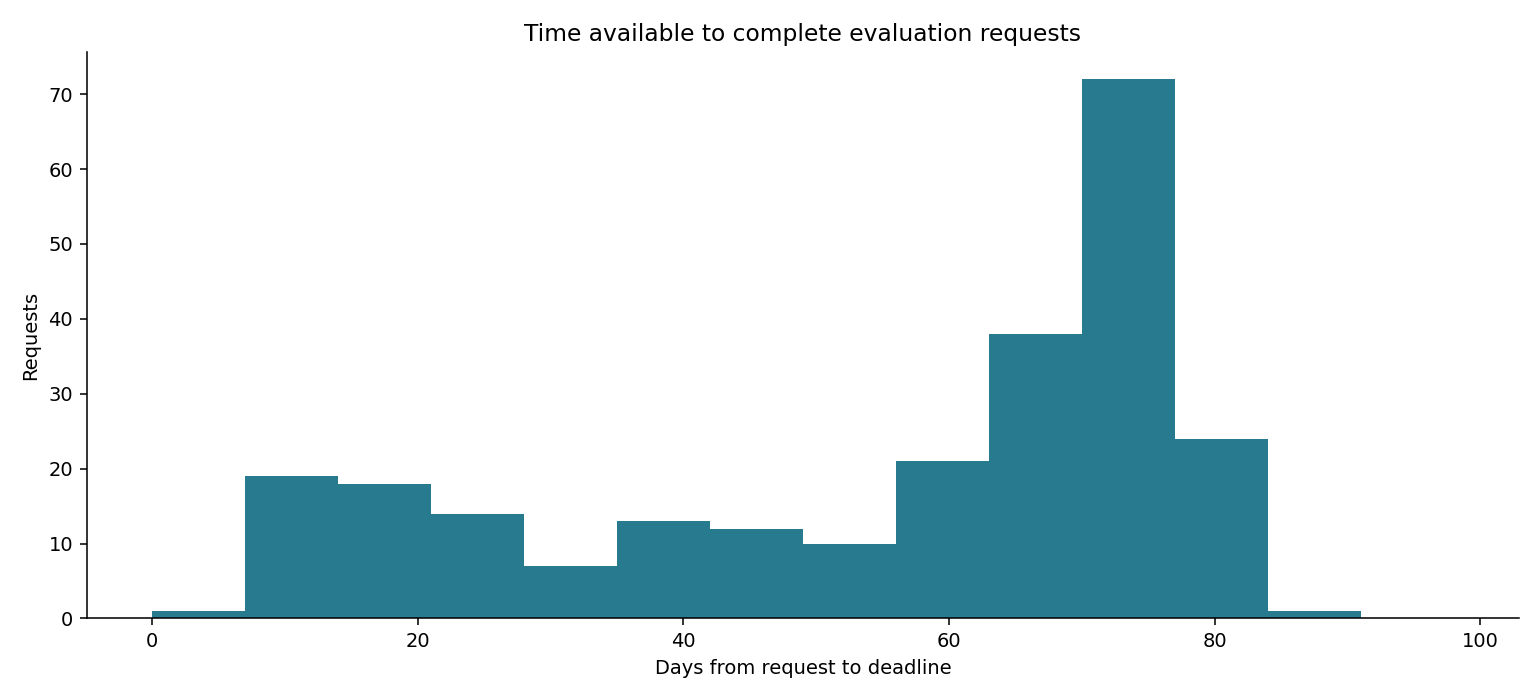

### Extract Insights

- Deadlines span 6–86 days; median 65 days.
- 55/250 (22.0%) must complete within 30 days.

### Implications for the Financial Agent

- **DETERMINISTIC:** Compute completion eligibility using each request date and deadline, independently of the forecast horizon.

In [3]:
display(Code(inspect.getsource(Analysis.requests), language="python"))
a.requests()

## Payment preferences

### Query / Analysis

Count accepted method combinations and restrictive preferences among evaluation users.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

def preferences(self):
        c=self.r.payment_methods_user_will_consider.value_counts(); fig,ax=plt.subplots(figsize=(12,5)); self.bar(ax,c,'Accepted payment-method combinations','Users','Accepted methods'); self.plot('04_preferences',fig)
        count=self.r.payment_methods_user_will_consider.str.split('|').str.len()
        self.findings('preferences',{'combinations':c.to_dict(),'single_method':int(count.eq(1).sum()),'restricted':int(count.lt(3).sum()),'partial_allowed':int(self.r.allows_partial_payment.astype(str).str.lower().eq('true').sum())},[
            f"{count.lt(3).sum()}/{len(count)} ({count.lt(3).mean():.1%}) users exclude at least one immediate payment method.",
            f"{count.eq(1).sum()} users ({count.eq(1).mean():.1%}) accept exactly one method; request-level partial permission still needs a separate check."], [('DETERMINISTIC','Filter payment candidates by user acceptance before ranking; financial capacity and method eligibility are distinct.')])

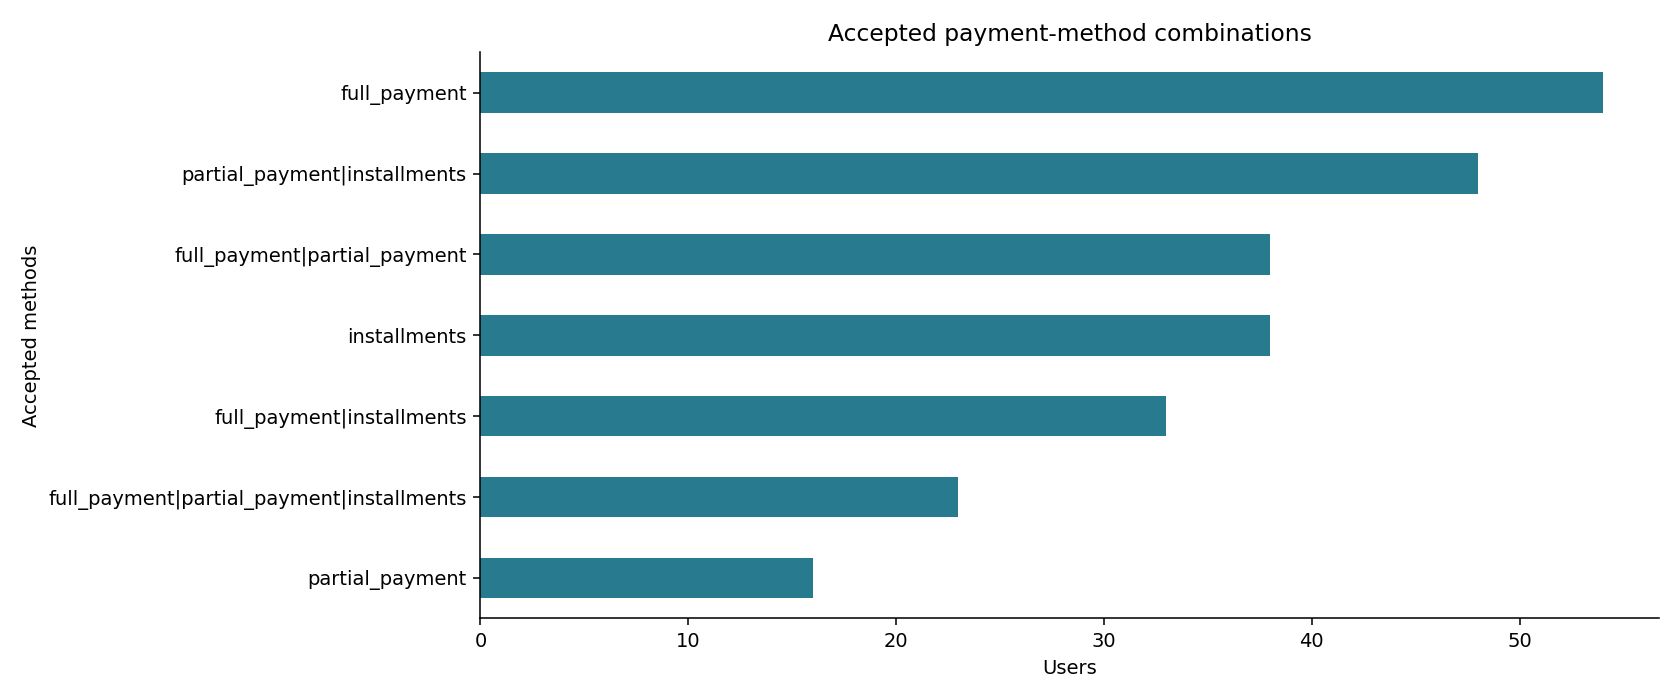

### Extract Insights

- 227/250 (90.8%) users exclude at least one immediate payment method.
- 108 users (43.2%) accept exactly one method; request-level partial permission still needs a separate check.

### Implications for the Financial Agent

- **DETERMINISTIC:** Filter payment candidates by user acceptance before ranking; financial capacity and method eligibility are distinct.

In [4]:
display(Code(inspect.getsource(Analysis.preferences), language="python"))
a.preferences()

## Financial-event distributions

### Query / Analysis

Count status, type, category and per-user event volume for evaluation users, including rare cash states.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

def events(self):
        c=self.e.status.value_counts(); fig,axes=plt.subplots(1,2,figsize=(12,5)); self.bar(axes[0],c,'Event status: full population','Events','Status'); self.bar(axes[1],c.drop('settled',errors='ignore'),'Event status: non-settled detail','Events','Status'); self.plot('05_status',fig)
        self.findings('event_status',c.to_dict(),[f"Settled rows account for {c.get('settled',0)}/{len(self.e)} ({c.get('settled',0)/len(self.e):.1%}) evaluation-user events.",f"There are {c.get('pending',0)} pending and {c.get('unrealized',0)} unrealized rows; these require different cash treatment despite their small frequency."], [('DETERMINISTIC','Reserve pending debits; exclude pending credits and unrealized value from available cash. Failed collections may leave liabilities.')])
        types=self.e.event_type.value_counts(); cats=self.e.category.value_counts(); fig,axes=plt.subplots(1,2,figsize=(13,6)); self.bar(axes[0],types,'Financial-event types','Events','Type'); self.bar(axes[1],cats.head(10),'Ten most frequent event categories','Events','Category'); self.plot('06_event_types',fig)
        self.findings('event_types',{'types':types.to_dict(),'categories':cats.to_dict()},[f"{types.index[0]} contributes {types.iloc[0]:,} events ({types.iloc[0]/len(self.e):.1%}).",f"The three most frequent categories ({', '.join(cats.head(3).index)}) account for {cats.head(3).sum()/len(self.e):.1%} of events."], [('STATISTICAL','Recurring obligations and essential variable spending need separate estimation; an expense type does not establish recurrence.')])
        n=self.e.groupby('user_id').size().reindex(self.r.user_id,fill_value=0); fig,ax=plt.subplots(); ax.hist(n,bins=20,color='#287b8e'); ax.set(title='Historical and supplied event counts per evaluation user',xlabel='Event rows per user',ylabel='Users'); self.plot('07_event_counts',fig)
        self.findings('event_counts',n.describe().to_dict(),[f"Users have {n.min()}–{n.max()} rows; median {n.median():.0f}, IQR {n.quantile(.25):.0f}–{n.quantile(.75):.0f}.",f"{n.gt(n.quantile(.75)).sum()} users exceed the upper-quartile event count; row volume alone is not evidence complexity."], [('DETERMINISTIC','Retrieve and process per-user histories; avoid sending the entire event table to an interpreter.')])

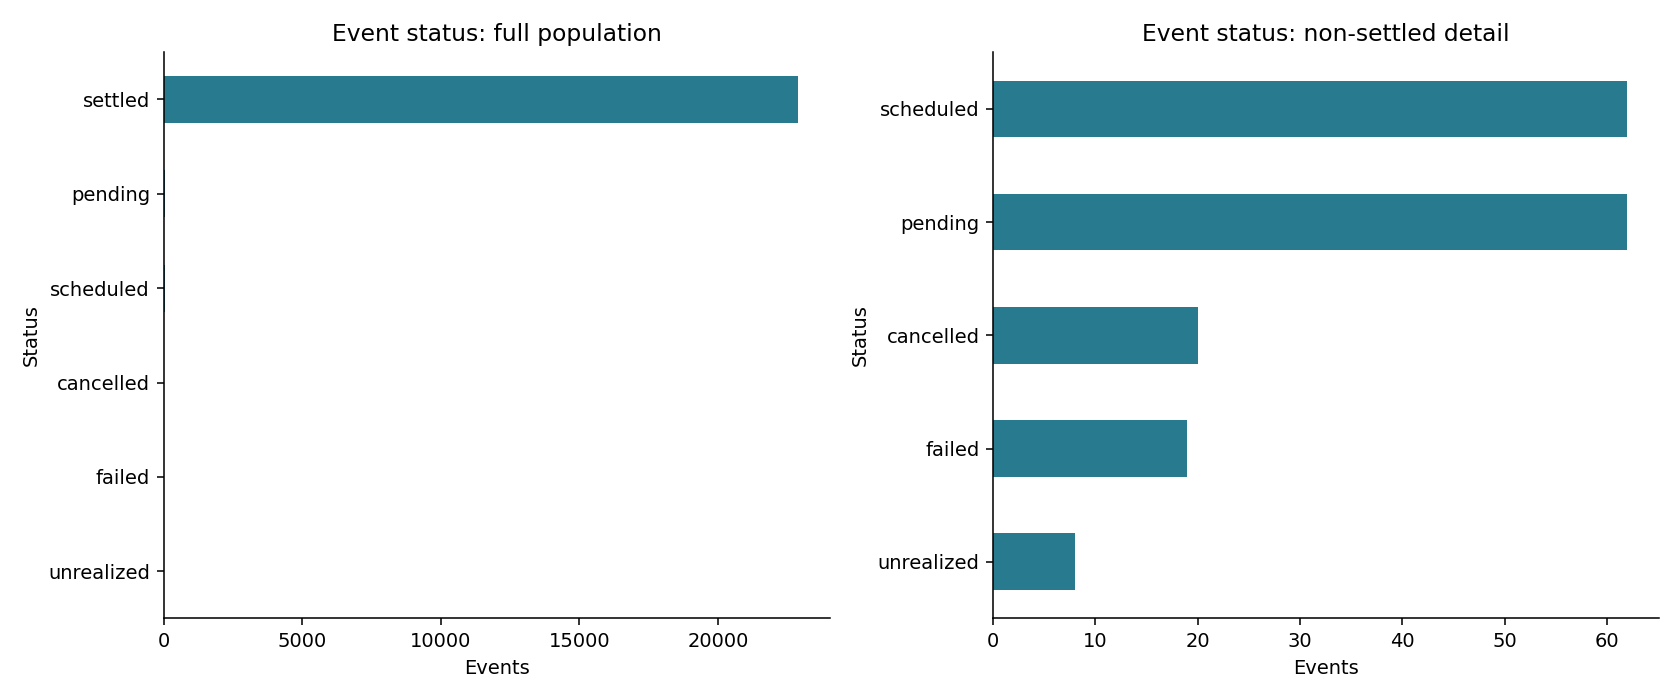

### Extract Insights

- Settled rows account for 22883/23054 (99.3%) evaluation-user events.
- There are 62 pending and 8 unrealized rows; these require different cash treatment despite their small frequency.

### Implications for the Financial Agent

- **DETERMINISTIC:** Reserve pending debits; exclude pending credits and unrealized value from available cash. Failed collections may leave liabilities.

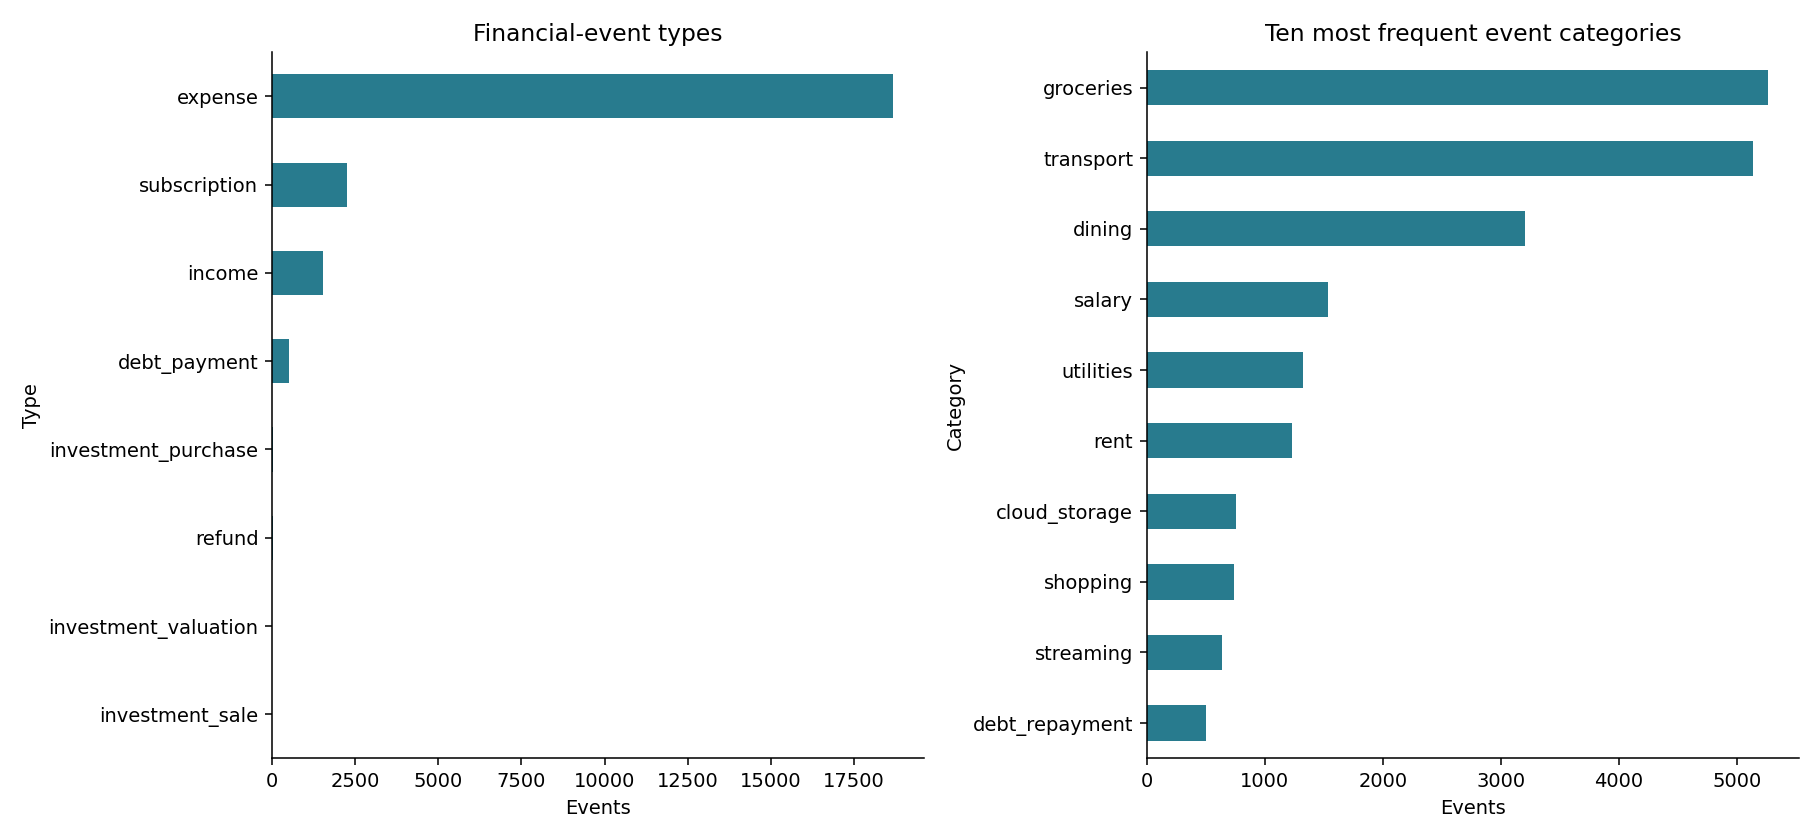

### Extract Insights

- expense contributes 18,677 events (81.0%).
- The three most frequent categories (groceries, transport, dining) account for 59.0% of events.

### Implications for the Financial Agent

- **STATISTICAL:** Recurring obligations and essential variable spending need separate estimation; an expense type does not establish recurrence.

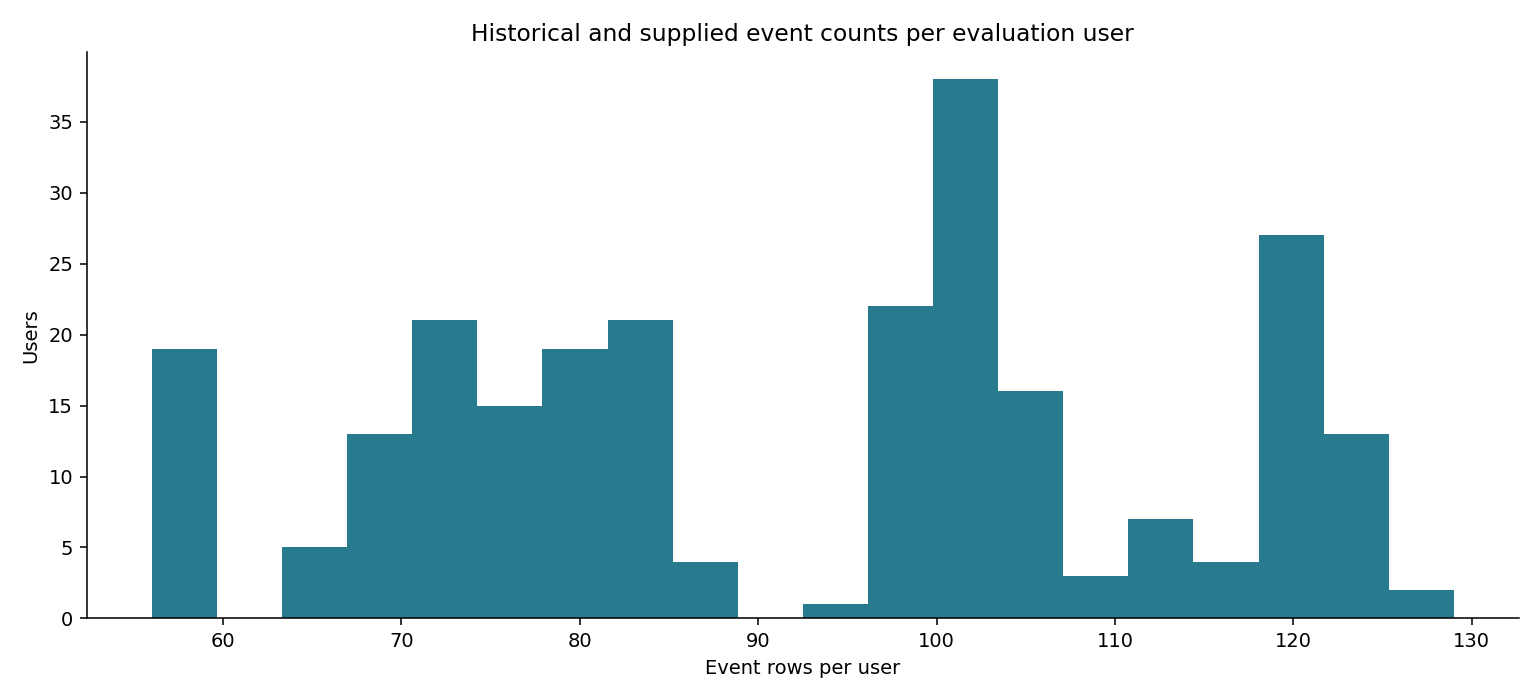

### Extract Insights

- Users have 56–129 rows; median 98, IQR 75–104.
- 60 users exceed the upper-quartile event count; row volume alone is not evidence complexity.

### Implications for the Financial Agent

- **DETERMINISTIC:** Retrieve and process per-user histories; avoid sending the entire event table to an interpreter.

In [5]:
display(Code(inspect.getsource(Analysis.events), language="python"))
a.events()

## Recurring candidates and chronological backtesting

### Query / Analysis

Group settled pre-request cash history by user, normalized description, category, direction and currency. Aggregate same-day amounts within groups (all-missing stays missing); require four distinct dates. Use expanding windows with three prior observations minimum. Compare four date and three amount heuristics, average folds within series then weight series equally. No sample answers are used. Cadence breakdowns are descriptive full-history strata, not predictors supplied to folds.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

def recurrence(self):
        h=self.e.loc[self.e.status.eq('settled') & self.e.direction.isin(['credit','debit']) & self.e.date.lt(pd.to_datetime(self.e.request_date))].copy()
        h['normalized_description']=h.description.str.lower().str.replace(r'\s+',' ',regex=True).str.strip()
        keys=['user_id','normalized_description','category','direction','currency']
        series=[]; errors=[]; intervals=[]
        for sid,(key,g) in enumerate(h.groupby(keys,sort=True)):
            # Same-day rows are aggregated within the declared series; all-missing days stay missing.
            daily=g.groupby('date').amount.sum(min_count=1).sort_index()
            if len(daily)<4: continue
            dates=daily.index; values=daily.to_numpy(dtype=float); gaps=np.diff(dates.values).astype('timedelta64[D]').astype(float)
            cv=np.nanstd(values)/abs(np.nanmean(values)) if np.nanmean(values)!=0 else np.nan
            median_gap=float(np.median(gaps)); iqr=float(np.quantile(gaps,.75)-np.quantile(gaps,.25))
            cadence='monthly_candidate' if 28<=median_gap<=32 else 'weekly_candidate' if 6<=median_gap<=8 else 'other'
            series.append(dict(series_id=sid,user_id=key[0],description=key[1],category=key[2],direction=key[3],currency=key[4],n_dates=len(dates),median_gap=median_gap,interval_iqr=iqr,amount_cv=cv,cadence=cadence))
            intervals.extend(gaps.tolist())
            for cut in range(3,len(dates)):
                train=dates[:cut]; actual=dates[cut]; prior=values[:cut]; target=values[cut]
                delta=np.diff(train.values).astype('timedelta64[D]').astype(float)
                day=int(pd.Series(train.day).mode().iloc[0])
                preds={'fixed_30':train[-1]+pd.Timedelta(days=30),'last_interval':train[-1]+pd.Timedelta(days=float(delta[-1])),
                       'median_interval':train[-1]+pd.Timedelta(days=float(np.median(delta))),'calendar_month':next_month(train[-1],day)}
                assert max(train)<actual and actual<pd.Timestamp(g.request_date.iloc[0])
                for method,pred in preds.items():
                    errors.append(dict(series_id=sid,kind='date',method=method,error=abs((pred-actual).total_seconds())/86400,direction=key[3],cadence=cadence,train_end=str(train[-1].date()),target_date=str(actual.date()),request_date=g.request_date.iloc[0]))
                scale=np.nanmedian(abs(prior))
                if np.isfinite(target) and np.isfinite(scale) and scale>0:
                    for method,pred in {'last_amount':prior[-1],'historical_median':np.nanmedian(prior),'trailing_3_median':np.nanmedian(prior[-3:])}.items():
                        if np.isfinite(pred):errors.append(dict(series_id=sid,kind='amount',method=method,error=abs(pred-target)/scale,direction=key[3],cadence=cadence,train_end=str(train[-1].date()),target_date=str(actual.date()),request_date=g.request_date.iloc[0]))
        self.series=pd.DataFrame(series); self.errors=pd.DataFrame(errors)
        self.series.to_csv(OUT/'tables/recurring_candidates.csv',index=False); self.errors.to_csv(OUT/'tables/recurrence_folds.csv',index=False)
        s=self.series; fig,axes=plt.subplots(1,2,figsize=(12,5)); axes[0].hist(intervals,bins=35,color='#287b8e'); axes[0].set(title='All candidate-series observed intervals',xlabel='Days between distinct settlement dates',ylabel='Intervals'); axes[1].hist(s.median_gap,bins=30,color='#287b8e'); axes[1].set(title='Median interval per candidate series',xlabel='Median interval (days)',ylabel='Series'); self.plot('08_recurrence_intervals',fig)
        self.findings('recurrence_intervals',{'series':len(s),'users':s.user_id.nunique(),'intervals':len(intervals),'monthly_share':s.median_gap.between(28,32).mean(),'weekly_share':s.median_gap.between(6,8).mean(),'iqr_above_7_share':s.interval_iqr.gt(7).mean(),'same_day_aggregation':'sum within exact grouping, min_count=1'},[
            f"{len(s)} candidates across {s.user_id.nunique()} users have at least four distinct historical 

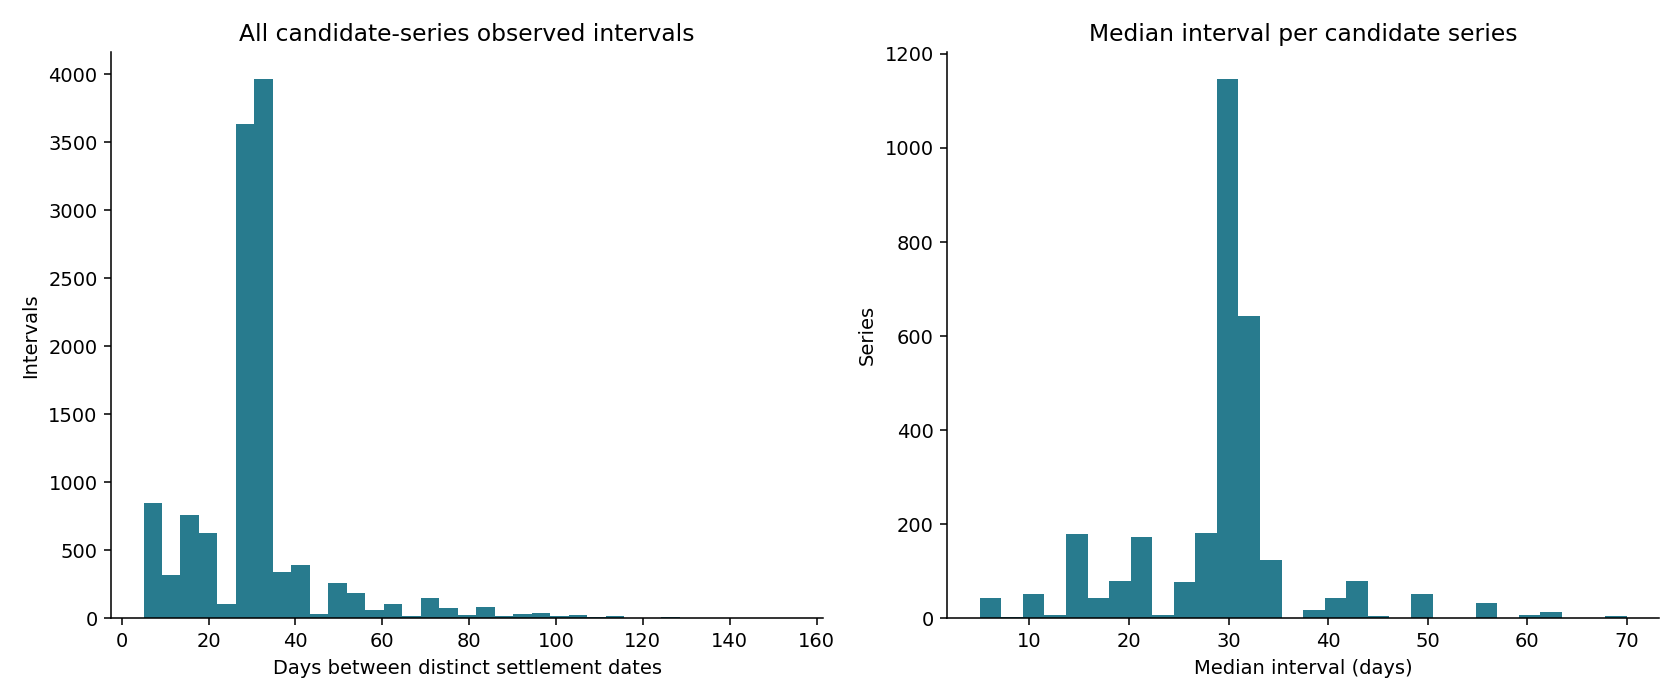

### Extract Insights

- 3022 candidates across 250 users have at least four distinct historical settlement dates.
- 64.7% have median intervals of 28–32 days; 1.4% fall in 6–8 days.
- 1195 (39.5%) have interval IQR above seven days; description-based groups are candidates, not confirmed obligations.

### Implications for the Financial Agent

- **STATISTICAL:** Infer cadence from history rather than assuming 30 days. Different descriptions may fragment one obligation; one description may merge multiple obligations.

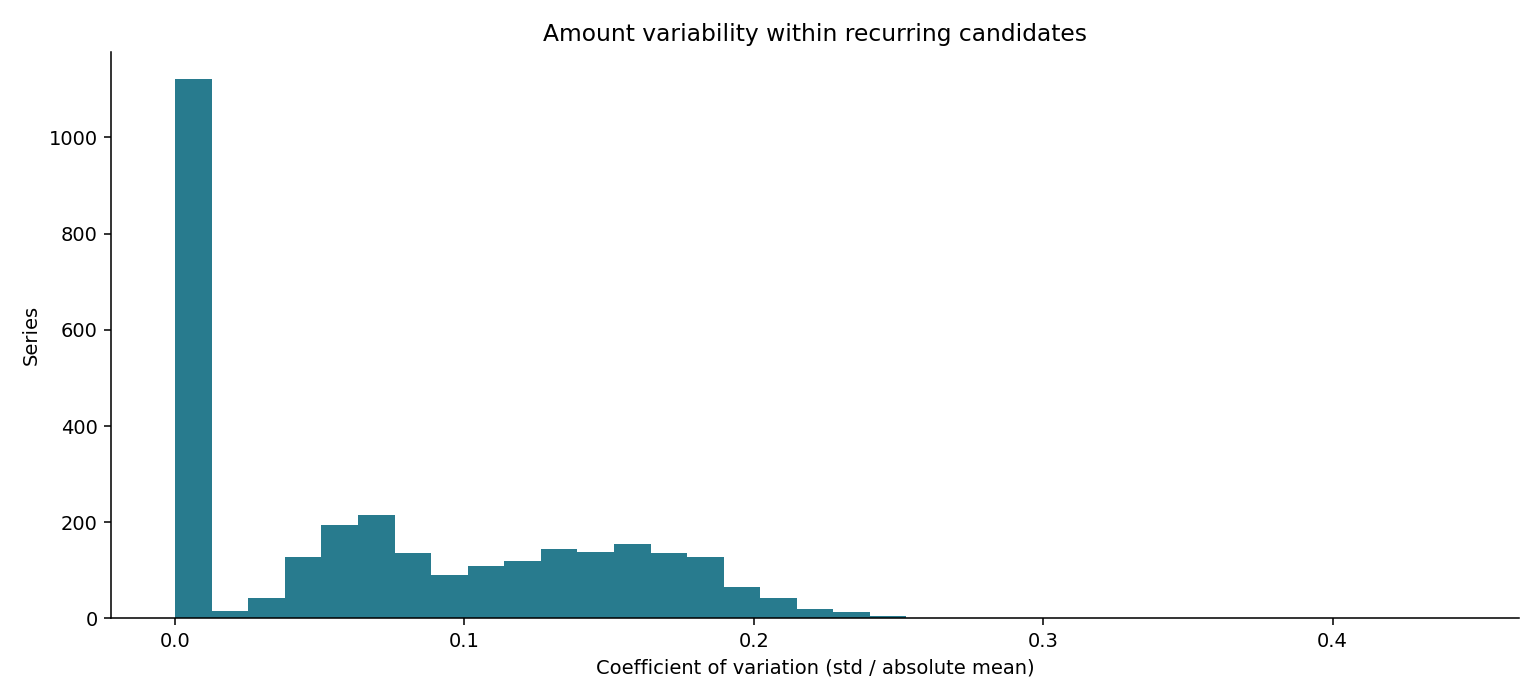

### Extract Insights

- Median amount CV is 0.064; 95th percentile is 0.189.
- 7/3022 measurable series exceed CV 0.25; 0 have undefined CV.

### Implications for the Financial Agent

- **STATISTICAL:** Compare robust amount estimators; point-error accuracy alone does not guarantee conservative expense reserves.

,kind,method,mean_error,series,folds
0,amount,historical_median,0.089737,3022,6122
1,amount,last_amount,0.100434,3022,6122
2,amount,trailing_3_median,0.091593,3022,6122
3,date,calendar_month,8.936871,3022,6122
4,date,fixed_30,8.710259,3022,6122
5,date,last_interval,13.342191,3022,6122
6,date,median_interval,11.414965,3022,6122


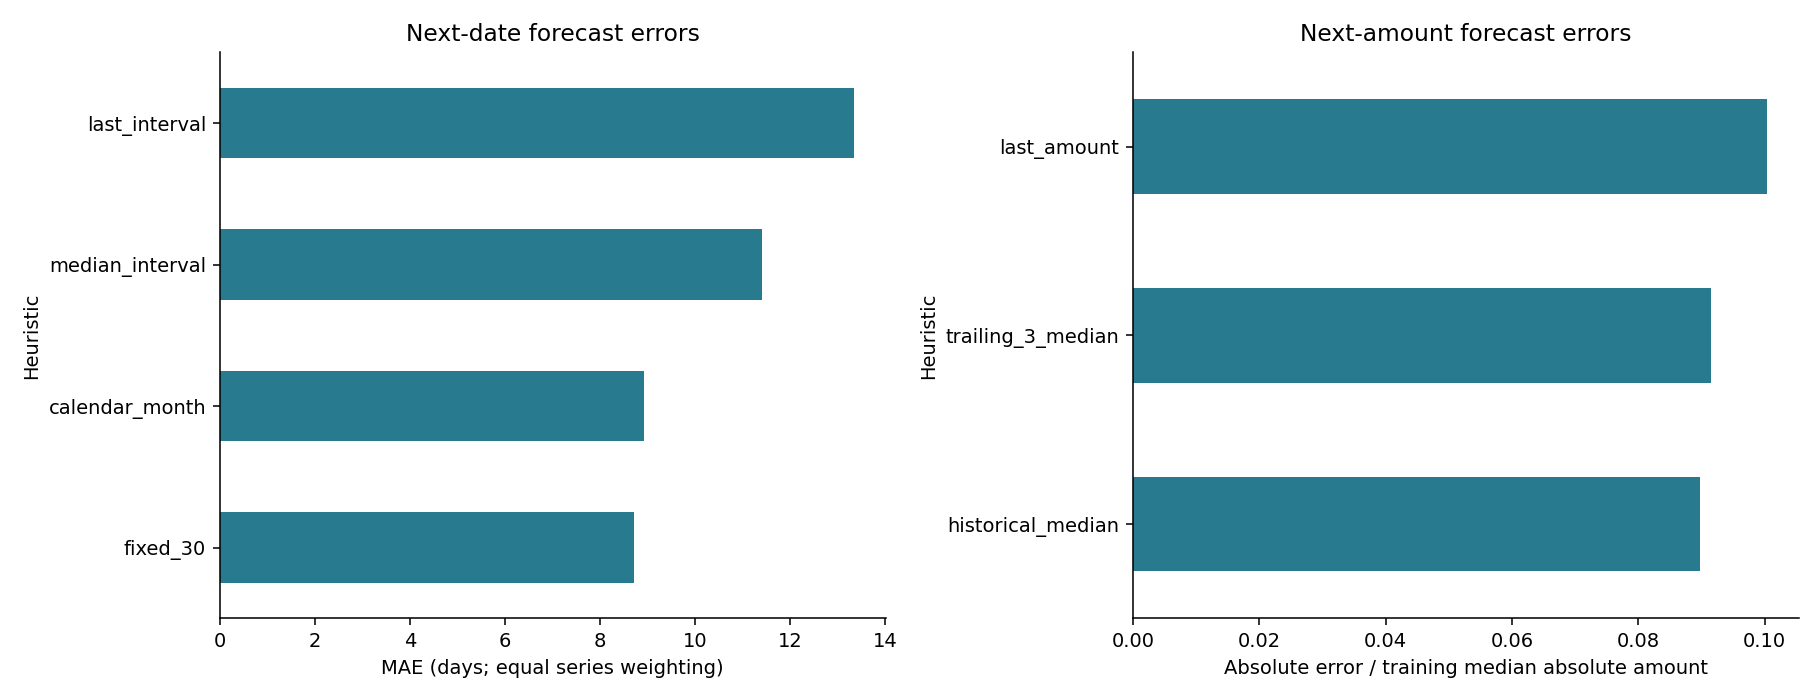

### Extract Insights

- Lowest date error: fixed_30, 8.710 days across 3022 series and 6122 folds.
- Lowest amount error: historical_median, 0.0897 normalized absolute error across 3022 series.
- The benchmark contains 42,854 method/fold rows; missing target or unscalable amount folds are excluded. These are one-step historical results, not a 90-day safety evaluation.

### Implications for the Financial Agent

- **STATISTICAL:** Use the observed winners as baselines and inspect direction/cadence breakdowns; validate conservative tails and regime changes separately.
- **EDGE_CASE:** Calendar months clip at month end; fixed-day and calendar-month recurrence are distinct. Ties are reported, not hidden.

In [6]:
display(Code(inspect.getsource(Analysis.recurrence), language="python"))
a.recurrence()

## Payment-option schedules and arithmetic

### Query / Analysis

Check native-unit arithmetic to 0.01 absolute tolerance, exact-day schedules, deadlines, accepted methods and a declared payment-count screen for installment limits.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

def options(self):
        o=self.o.copy(); inst=o[o.payment_method.eq('installments')]; fig,axes=plt.subplots(1,2,figsize=(12,5)); self.bar(axes[0],inst.payment_frequency_days.astype(str).value_counts(),'Installment intervals','Offers','Days'); self.bar(axes[1],inst.number_of_payments.value_counts().sort_index(),'Installment payment counts','Offers','Number of payments'); self.plot('11_payment_options',fig)
        num=lambda c:pd.to_numeric(o[c],errors='coerce')
        # Relative tolerance is inappropriate for large currency amounts; use one hundredth native unit.
        o['arithmetic_bad']=(num('payment_amount')*num('number_of_payments')-num('total_payable_amount')).abs().gt(.01)
        o['fee_bad']=(num('total_payable_amount')-o.requested_amount-num('financing_fee')).abs().gt(.01)
        days=num('payment_frequency_days').fillna(0)*(num('number_of_payments')-1)
        o['last_payment_date']=pd.to_datetime(o.first_payment_date)+pd.to_timedelta(days,unit='D')
        o['after_deadline']=o.last_payment_date.gt(pd.to_datetime(o.desired_completion_date))
        o['method_rejected']=[m not in a.split('|') for m,a in zip(o.payment_method,o.payment_methods_user_will_consider)]
        o['above_installment_count_limit']=o.payment_method.eq('installments') & (num('number_of_payments').gt(num('max_installment_months')) | num('max_installment_months').isna())
        checks={k:int(o[k].sum()) for k in ['arithmetic_bad','fee_bad','after_deadline','method_rejected','above_installment_count_limit']}
        self.table('option_validation',o[['payment_option_id','request_id','last_payment_date']+list(checks)])
        self.findings('payment_options',{'offers':len(o),'installments':len(inst),'intervals':inst.payment_frequency_days.value_counts().to_dict(),'checks':checks,'installment_limit_screen':'number_of_payments > max_installment_months; count-based EDA screen, not final month-duration interpretation'},[
            f"Evaluation requests have {len(o)} offers, including {len(inst)} installment offers using {sorted(inst.payment_frequency_days.astype(str).unique())}-day intervals.",f"Arithmetic discrepancies above 0.01 native units: {checks['arithmetic_bad']} payment-total and {checks['fee_bad']} principal-plus-fee mismatches.",f"{checks['after_deadline']} offers finish after the deadline; {checks['method_rejected']} use rejected methods; {checks['above_installment_count_limit']} fail the declared installment-count screen. These flags can overlap."], [('DETERMINISTIC','Calculate schedules with exact day intervals and validate fees, deadlines and preferences before cash simulation.'),('EDGE_CASE','The month-limit screen uses payment count; resolve duration interpretation explicitly before implementing final eligibility.')])

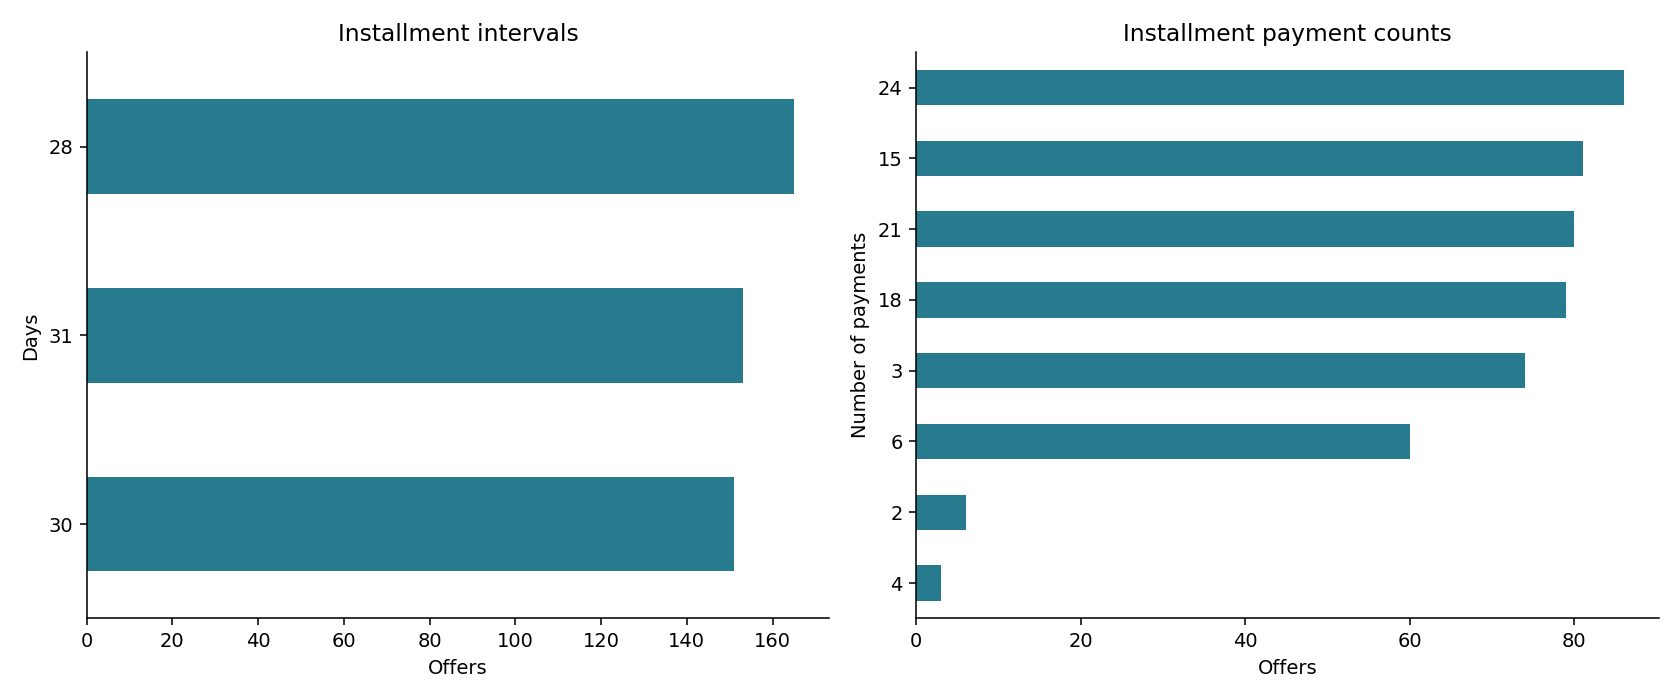

,payment_option_id,request_id,last_payment_date,arithmetic_bad,fee_bad,after_deadline,method_rejected,above_installment_count_limit
0,payment_option_72,request_26,2025-08-03,False,False,False,False,False
1,payment_option_73,request_26,2026-09-30,False,False,True,False,True
2,payment_option_74,request_26,2026-01-12,False,False,True,False,True
3,payment_option_75,request_26,2027-05-23,False,False,True,False,True
4,payment_option_76,request_27,2026-07-05,False,False,False,False,False
5,payment_option_77,request_27,2027-12-21,False,False,True,True,True
6,payment_option_78,request_28,2024-06-07,False,False,False,False,False
7,payment_option_79,request_28,2026-01-02,False,False,True,True,True
8,payment_option_80,request_28,2026-05-24,False,False,True,True,True
9,payment_option_81,request_29,2025-11-04,False,False,False,False,False


Showing 15 of 719 rows; complete table: `eda_outputs/tables/option_validation.csv`.

### Extract Insights

- Evaluation requests have 719 offers, including 469 installment offers using ['28', '30', '31']-day intervals.
- Arithmetic discrepancies above 0.01 native units: 0 payment-total and 0 principal-plus-fee mismatches.
- 394 offers finish after the deadline; 310 use rejected methods; 381 fail the declared installment-count screen. These flags can overlap.

### Implications for the Financial Agent

- **DETERMINISTIC:** Calculate schedules with exact day intervals and validate fees, deadlines and preferences before cash simulation.
- **EDGE_CASE:** The month-limit screen uses payment count; resolve duration interpretation explicitly before implementing final eligibility.

In [7]:
display(Code(inspect.getsource(Analysis.options), language="python"))
a.options()

## Message taxonomy, image triage and lifecycle transitions

### Query / Analysis

Apply provisional multilingual regex topic flags to evaluation-user messages; allow multiple topics and retain unmatched text as unclassified. Count linked status transitions. Three supplied images were manually inspected for document structure only; full fact normalization is deferred.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

In [8]:
display(Code(inspect.getsource(Analysis.evidence), language="python"))
a.evidence()

def evidence(self):
        patterns={'payroll':r'salary|payroll|gaji|penggajian|employer|stipend',
            'timing_change':r'delay|revised|reschedul|later|replaces|ditunda|tertunda',
            'amount_change':r'increase|raise|reduc|renew|naik|berubah',
            'cancellation_or_end':r'cancel|ended|terminated|off-season|berakhir',
            'unsettled_or_dispute':r'pending|disput|investigat|not.*posted|awaiting|failed|retry|retried',
            'transfer_or_multiple_accounts':r'transfer|two.*accounts|separate.*accounts|two.*card'}
        tags=pd.DataFrame({k:self.m.message_text.str.contains(v,case=False,regex=True,na=False) for k,v in patterns.items()})
        tags['unmatched']=~tags.any(axis=1); counts=tags.sum().sort_values(ascending=False)
        self.table('message_taxonomy',counts); self.m.assign(**{c:tags[c] for c in tags})[['message_id','user_id']+list(tags)].to_csv(OUT/'tables/message_topic_flags.csv',index=False)
        future=pd.to_datetime(self.m.sent_at,utc=True).dt.date > pd.to_datetime(self.m.user_id.map(self.r.set_index('user_id').request_date)).dt.date
        self.findings('message_triage',{'messages':len(self.m),'users':self.m.user_id.nunique(),'topic_counts':counts.to_dict(),'patterns':patterns,'multi_topic':int(tags.drop(columns='unmatched').sum(axis=1).gt(1).sum()),'after_request_day':int(future.sum()),'blank_event_links':int(self.m.related_event_id.eq('').sum()),'reviewed_images':{'image_01':'payslip: earnings/deductions/net pay','image_03':'retail receipt: item lines/net/cash paid','image_09':'utility receipt: charge/due dates and received amount'},'image_review_scope':'three representative images across all supplied users; personal details not transcribed'},[
            f"{len(self.m)} evaluation-user messages cover {self.m.user_id.nunique()}/{len(self.r)} users; {self.m.related_event_id.eq('').sum()} lack a direct event link.",f"{int(tags.unmatched.sum())} messages are unmatched by the provisional multilingual patterns; {int(tags.drop(columns='unmatched').sum(axis=1).gt(1).sum())} match multiple topics, which does not itself prove conflict.",f"{future.sum()} messages are dated after their request day; same-day availability cannot be resolved from a date-only request.",f"Three representative supplied images were visually inspected: a payslip, retail receipt, and utility receipt. EDA leaves all {self.e.amount.isna().sum()} evaluation-user missing amounts unresolved."], [('LLM_REQUIRED','Interpret amendments, effective dates and document-specific amounts with provenance; keyword triage is not fact extraction or proof of model necessity.'),('EDGE_CASE','Filter evidence by availability; request dates lack time-of-day precision. Never export raw personal document details.')])
        all_e=self.t['financial_events'].set_index('event_id'); links=self.e[self.e.linked_event_id.ne('')].copy(); links['previous_status']=links.linked_event_id.map(all_e.status); trans=links.groupby(['previous_status','status']).size().rename('rows').reset_index(); self.table('lifecycle_transitions',trans)
        self.findings('lifecycle',{'linked_rows':len(links),'users':links.user_id.nunique(),'transitions':trans.to_dict('records')},[f"{len(links)} linked evaluation-user rows occur across {links.user_id.nunique()} users ({links.user_id.nunique()/len(self.r):.1%}).",f"The links exhibit {len(trans)} status-transition combinations; transitions describe row relationships, not resolved duplicates or cash obligations."], [('DETERMINISTIC','Traverse lifecycle links and retain cash status rather than dropping all linked rows.'),('LLM_REQUIRED','Use evidence to distinguish cancellation, settlement, transfers and still-outstanding liabilities when structured rows are insufficient.')])

,value,count
0,payroll,117
1,amount_change,44
2,unsettled_or_dispute,35
3,unmatched,31
4,cancellation_or_end,19
5,timing_change,15
6,transfer_or_multiple_accounts,7


### Extract Insights

- 198 evaluation-user messages cover 198/250 users; 162 lack a direct event link.
- 31 messages are unmatched by the provisional multilingual patterns; 58 match multiple topics, which does not itself prove conflict.
- 0 messages are dated after their request day; same-day availability cannot be resolved from a date-only request.
- Three representative supplied images were visually inspected: a payslip, retail receipt, and utility receipt. EDA leaves all 11 evaluation-user missing amounts unresolved.

### Implications for the Financial Agent

- **LLM_REQUIRED:** Interpret amendments, effective dates and document-specific amounts with provenance; keyword triage is not fact extraction or proof of model necessity.
- **EDGE_CASE:** Filter evidence by availability; request dates lack time-of-day precision. Never export raw personal document details.

,previous_status,status,rows
0,cancelled,settled,7
1,failed,scheduled,7
2,settled,pending,13
3,settled,settled,17
4,settled,unrealized,8


### Extract Insights

- 52 linked evaluation-user rows occur across 48 users (19.2%).
- The links exhibit 5 status-transition combinations; transitions describe row relationships, not resolved duplicates or cash obligations.

### Implications for the Financial Agent

- **DETERMINISTIC:** Traverse lifecycle links and retain cash status rather than dropping all linked rows.
- **LLM_REQUIRED:** Use evidence to distinguish cancellation, settlement, transfers and still-outstanding liabilities when structured rows are insufficient.

## Exchange-rate coverage and pending reserves

### Query / Analysis

Match directed settlement-date rates without fallback. Sum known pending debits per user; exclude incomplete totals and nonpositive headroom from ratio statistics.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

In [9]:
display(Code(inspect.getsource(Analysis.fx_pending), language="python"))
a.fx_pending()

def fx_pending(self):
        rates=self.t['exchange_rates']; duplicate=int(rates.duplicated(['rate_date','from_currency','to_currency']).sum())
        lookup=rates.drop_duplicates(['rate_date','from_currency','to_currency']).set_index(['rate_date','from_currency','to_currency']).rate.to_dict()
        e=self.e.copy(); e['fx_rate']=[1.0 if not foreign else lookup.get((date,cur,home),np.nan) for foreign,date,cur,home in zip(e.foreign,e.settlement_date,e.currency,e.home_currency)]
        e['home_amount']=e.amount*pd.to_numeric(e.fx_rate,errors='coerce'); self.converted=e
        foreign=e[e.foreign & e.direction.isin(['credit','debit'])]; missing=foreign[foreign.fx_rate.isna()]
        self.table('fx_missing',missing[['event_id','user_id','settlement_date','currency','home_currency','status']])
        self.findings('fx_coverage',{'rate_rows':len(rates),'duplicate_keys':duplicate,'foreign_cash_rows':len(foreign),'missing_rate_rows':len(missing),'missing_event_ids':missing.event_id.tolist()},[f"{len(foreign)} evaluation-user cash rows need conversion; {len(missing)} lack the exact dated directed rate.",f"The {len(rates)} supplied rates contain {duplicate} duplicate date/pair keys; no inverse, nearest-date, or live-rate fallback is applied."], [('DETERMINISTIC','Use settlement-date directed rates; fail explicitly on unresolved required conversions rather than inventing rates.')])
        pending=e[e.status.eq('pending')&e.direction.eq('debit')]; totals=pending.groupby('user_id').home_amount.sum(min_count=1)
        unknown=set(pending.loc[pending.home_amount.isna(),'user_id']); complete=totals.drop(index=list(unknown),errors='ignore'); head=self.r.set_index('user_id').headroom
        ratios=complete/head.reindex(complete.index).where(head.reindex(complete.index)>0)
        self.table('pending_debit_reserves',pd.DataFrame({'home_currency':self.r.set_index('user_id').home_currency.reindex(totals.index),'known_sum':totals,'incomplete':totals.index.isin(unknown),'ratio_to_positive_headroom':ratios}).reset_index())
        self.findings('pending_debits',{'rows':len(pending),'users':pending.user_id.nunique(),'incomplete_users':len(unknown),'ratio_quantiles':ratios.quantile([.5,.9,1]).to_dict(),'ratio_above_025':int(ratios.gt(.25).sum()),'nonpositive_headroom_users':int(head.reindex(complete.index).le(0).sum())},[f"{len(pending)} pending debit rows affect {pending.user_id.nunique()} users; {len(unknown)} users have incomplete amount/conversion evidence.",f"Among {ratios.notna().sum()} complete positive-headroom users, median pending debit/headroom is {ratios.median():.1%}; {ratios.gt(.25).sum()} exceed 25%."], [('DETERMINISTIC','Reserve pending debits per user; keep unknown reserves explicit rather than treating missing amounts as zero.')])

,event_id,user_id,settlement_date,currency,home_currency,status


### Extract Insights

- 134 evaluation-user cash rows need conversion; 0 lack the exact dated directed rate.
- The 134 supplied rates contain 0 duplicate date/pair keys; no inverse, nearest-date, or live-rate fallback is applied.

### Implications for the Financial Agent

- **DETERMINISTIC:** Use settlement-date directed rates; fail explicitly on unresolved required conversions rather than inventing rates.

,user_id,home_currency,known_sum,incomplete,ratio_to_positive_headroom
0,user_100,ZAR,1027.40,False,0.028647
1,user_101,INR,15660.00,False,0.056236
2,user_102,EUR,86.00,False,0.022972
3,user_103,INR,7490.00,False,0.173183
4,user_120,IDR,587100.00,False,0.050185
5,user_121,USD,25.00,False,0.026567
6,user_122,IDR,950000.00,False,0.021474
7,user_123,IDR,1388900.00,False,0.030448
8,user_138,EUR,134.75,False,0.100212
9,user_140,ZAR,2004.20,False,0.153238


Showing 15 of 55 rows; complete table: `eda_outputs/tables/pending_debit_reserves.csv`.

### Extract Insights

- 55 pending debit rows affect 55 users; 1 users have incomplete amount/conversion evidence.
- Among 54 complete positive-headroom users, median pending debit/headroom is 5.1%; 0 exceed 25%.

### Implications for the Financial Agent

- **DETERMINISTIC:** Reserve pending debits per user; keep unknown reserves explicit rather than treating missing amounts as zero.

## Request complexity and example timeline

### Query / Analysis

Give one point each for messages, images/missing amounts, lifecycle links, foreign currency, pending debits, restricted methods and irregular candidates (gap IQR > 7 days or amount CV > 0.25). Evidence-heavy means any of the first three evidence flags; simple means no evidence flags and score <= 1; remaining requests are structured-complex. Compare alternate irregularity thresholds. Select timeline by descending score, event count, then ascending request ID.

### Visualization and computed results

Plots are included where useful; detailed checks are exported as CSV tables.

def complexity(self):
        r=self.r.set_index('user_id'); s=self.series
        flags=pd.DataFrame(index=r.index)
        flags['messages']=flags.index.isin(self.m.user_id)
        flags['images_or_missing']=flags.index.isin(self.i.user_id)|flags.index.isin(self.e.loc[self.e.amount.isna(),'user_id'])
        flags['lifecycle']=flags.index.isin(self.e.loc[self.e.linked_event_id.ne(''),'user_id'])
        flags['foreign_currency']=flags.index.isin(self.e.loc[self.e.foreign,'user_id'])
        flags['pending_debit']=flags.index.isin(self.e.loc[self.e.status.eq('pending')&self.e.direction.eq('debit'),'user_id'])
        flags['restricted_methods']=r.payment_methods_user_will_consider.str.split('|').str.len().lt(3)
        flags['irregular_recurrence']=flags.index.isin(s.loc[s.interval_iqr.gt(7)|s.amount_cv.gt(.25),'user_id'])
        evidence=flags[['messages','images_or_missing','lifecycle']].any(axis=1); score=flags.sum(axis=1)
        tiers=pd.Series(np.where(evidence,'evidence-heavy',np.where(score<=1,'simple','structured-complex')),index=flags.index)
        result=flags.astype(int).assign(score=score,tier=tiers,request_id=r.request_id,event_count=self.e.groupby('user_id').size()).reset_index()
        self.complexity_table=result; self.table('request_complexity',result)
        counts=tiers.value_counts(); components=flags.sum().sort_values(ascending=False); fig,axes=plt.subplots(1,2,figsize=(13,5)); self.bar(axes[0],counts,'Request complexity: declared triage tiers','Requests','Tier'); self.bar(axes[1],components,'Prevalence of score components','Requests with flag','Component'); self.plot('12_complexity',fig)
        sensitivity=[]
        for gap,cv in [(5,.15),(7,.25),(10,.4)]:
            f=flags.copy(); f['irregular_recurrence']=f.index.isin(s.loc[s.interval_iqr.gt(gap)|s.amount_cv.gt(cv),'user_id']); sc=f.sum(axis=1)
            sensitivity.append({'interval_iqr_threshold':gap,'cv_threshold':cv,'simple':int((~evidence&sc.le(1)).sum()),'evidence_heavy':int(evidence.sum()),'structured_complex':int((~evidence&sc.gt(1)).sum()),'mean_score':sc.mean()})
        self.findings('complexity',{'tiers':counts.to_dict(),'components':components.to_dict(),'score_quantiles':score.quantile([0,.5,.75,1]).to_dict(),'sensitivity':sensitivity,'definitions':{'score':'one point per listed boolean flag','simple':'no evidence flags and score <= 1','evidence-heavy':'message, image/missing amount, or lifecycle flag','structured-complex':'remaining requests','irregular':'interval IQR > 7 days OR amount CV > 0.25'},'highest_requests':result.sort_values(['score','event_count','request_id'],ascending=[False,False,True]).head(10).to_dict('records')},[
            f"Under the declared rule: {counts.get('simple',0)} simple, {counts.get('structured-complex',0)} structured-complex, and {counts.get('evidence-heavy',0)} evidence-heavy evaluation requests.",f"Most prevalent score components: {components.index[0]} ({components.iloc[0]}/{len(r)}) and {components.index[1]} ({components.iloc[1]}/{len(r)}). These are score contributions, not independently validated difficulty predictors.",f"Across three irregularity thresholds, simple counts range {min(x['simple'] for x in sensitivity)}–{max(x['simple'] for x in sensitivity)}; evidence-heavy counts remain fixed by definition."], [('DETERMINISTIC','Use explicit flags for routing and audit priorities, not an opaque model-based complexity label.'),('EDGE_CASE','Evidence-heavy denotes evidence presence, not proven ambiguity; score rankings need validation against actual implementation effort.')])
        top=result.sort_values(['score','event_count','request_id'],ascending=[False,False,True]).iloc[0]; user=top.user_id
        ev=self.converted[self.converted.user_id.eq(user)].copy(); ev['timeline_date']=ev.date.fillna(pd.to_datetime(ev.event_date)); currency=r.loc[user,'home_currency']
        fig,ax=plt.subplots(figsize=(13,5))
        for status,g in ev.groupby('status'):
            signed=g.home_amount*np.wh

,user_id,messages,images_or_missing,lifecycle,foreign_currency,pending_debit,restricted_methods,irregular_recurrence,score,tier,request_id,event_count
0,user_26,1,0,1,0,0,1,1,4,evidence-heavy,request_26,76
1,user_27,1,0,0,0,0,1,1,3,evidence-heavy,request_27,114
2,user_28,1,0,0,0,0,1,1,3,evidence-heavy,request_28,103
3,user_29,1,0,0,0,0,0,0,1,evidence-heavy,request_29,79
4,user_30,0,0,0,0,0,1,1,2,structured-complex,request_30,72
5,user_31,0,0,0,0,0,1,1,2,structured-complex,request_31,99
6,user_32,1,0,0,0,0,1,1,3,evidence-heavy,request_32,98
7,user_33,1,1,0,0,0,1,1,4,evidence-heavy,request_33,122
8,user_34,1,0,0,0,0,1,1,3,evidence-heavy,request_34,72
9,user_35,1,1,1,0,0,1,1,5,evidence-heavy,request_35,108


Showing 15 of 250 rows; complete table: `eda_outputs/tables/request_complexity.csv`.

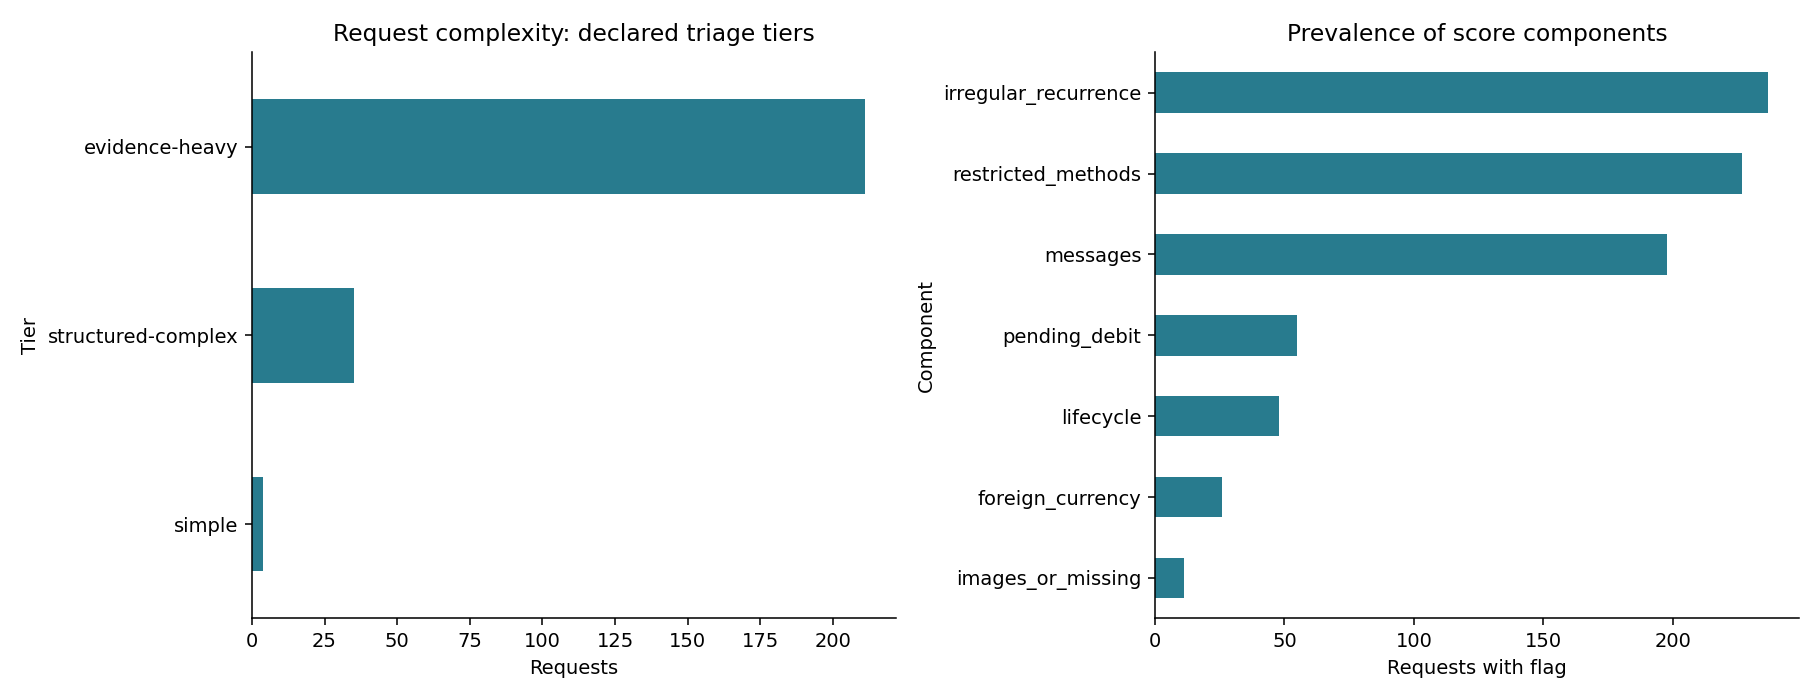

### Extract Insights

- Under the declared rule: 4 simple, 35 structured-complex, and 211 evidence-heavy evaluation requests.
- Most prevalent score components: irregular_recurrence (237/250) and restricted_methods (227/250). These are score contributions, not independently validated difficulty predictors.
- Across three irregularity thresholds, simple counts range 4–4; evidence-heavy counts remain fixed by definition.

### Implications for the Financial Agent

- **DETERMINISTIC:** Use explicit flags for routing and audit priorities, not an opaque model-based complexity label.
- **EDGE_CASE:** Evidence-heavy denotes evidence presence, not proven ambiguity; score rankings need validation against actual implementation effort.

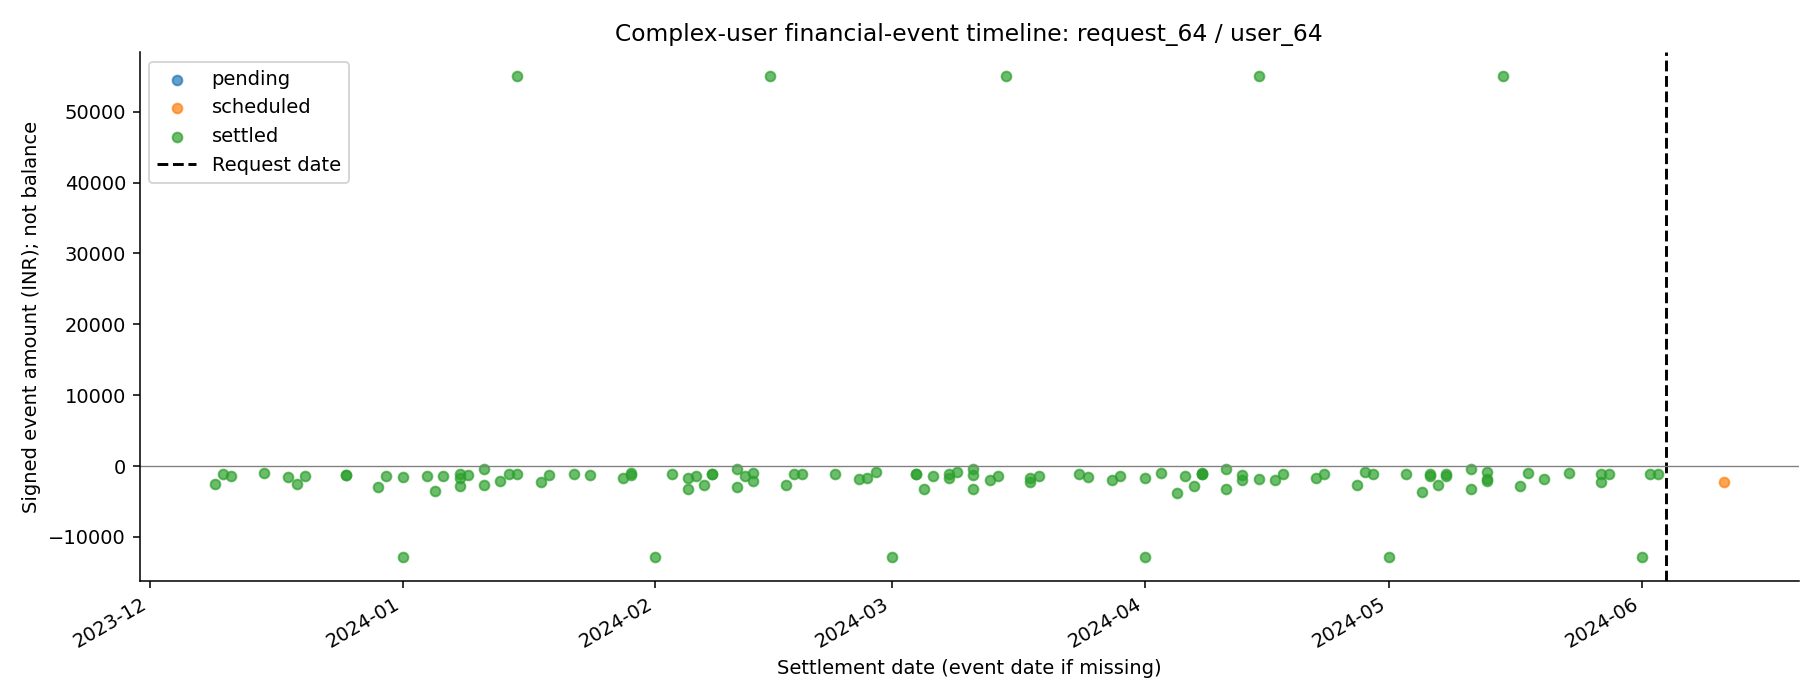

### Extract Insights

- request_64 has score 6/7 and 123 supplied events, selected by score, then event count, then request ID.
- 1 amounts cannot be plotted after exact-rate conversion; markers show cash-event records, not a reconstructed balance or recommended plan.

### Implications for the Financial Agent

- **DETERMINISTIC:** Build an auditable dated ledger before simulating balances; historical event plots must not be mistaken for current available cash.

In [10]:
display(Code(inspect.getsource(Analysis.complexity), language="python"))
a.complexity()

# EDA Conclusions for Architecture Design

The following answers are generated from the computed section results, not preset conclusions.

In [11]:
a.conclusions()

# EDA Conclusions for Architecture Design

### 1. What can be handled completely deterministically?

Identifier joins, typed parsing, preference filters, exact FX lookups, cash-state rules, supplied option arithmetic/schedules, output validation and plan simulation once financial facts are normalized.

### 2. What requires statistical inference?

Cadence, variable essential spending, and recurrence amount estimation: 39.5% of candidate series have interval IQR above seven days.

### 3. What needs LLM or vision interpretation?

198 evaluation-user messages and image-backed amounts require semantic triage/interpretation. The three reviewed document types have different monetary fields. This EDA does not establish that an LLM outperforms rules/OCR; test that in later ablations.

### 4. What financial-event patterns are most common?

expense is the largest event type (18,677 rows); settled rows dominate. 64.7% of recurrence candidates have a monthly-range median gap.

### 5. What are the major outliers and edge cases?

Nonpositive headroom: 0 requests; missing exact FX: 0 foreign cash rows; linked lifecycle records: 52. Missing image amounts, failed-but-outstanding bills and conflicting dates remain explicit review cases.

### 6. Which recurrence heuristic performed best?

Date winner(s): fixed_30, MAE 8.710 days. Amount winner(s): historical_median, normalized error 0.0897. Equal-series one-step backtesting does not establish a universally safe forecast.

### 7. Which variables most strongly affect complexity?

The largest declared score components are irregular_recurrence (237 requests), restricted_methods (227 requests), messages (198 requests). This is definitional contribution, not causal importance or a validated difficulty model.

### 8. How many requests are simple versus evidence-heavy?

Simple: 4; evidence-heavy: 211; structured-complex: 35. Tiers are exhaustive and mutually exclusive under the published triage rule.

### 9. Which assumptions are dangerous to hardcode?

Every month is 30 days; all salary continues indefinitely; latest amount repeats; linked means duplicate; failed means no remaining liability; pending credit is available; blank equals zero; all users accept full payment; headroom equals safe capacity; every message is available at request time.

### 10. What should the final architecture contain?

Validated ingestion and provenance → evidence interpretation with uncertainty → lifecycle and cash-state reconciliation → statistical recurrence/essential-spending forecasts → deterministic 90-day simulator → eligible plan generation/ranking → independent invariant checks → grounded explanations, final output and usage reporting. Route evidence by explicit flags, and introduce an LLM only after measured rule/OCR failures.

**Verification:** 13 figures, all evaluation requests assigned a tier, chronological holdouts checked, strict JSON saved, and input fingerprints unchanged.